In [1]:
import radiate as rd
import polars as pl

rd.random.seed(67123)

### Create a fake dataset 

This dataset is a simple polynomial regression problem with a small it of noise

In [2]:
def compute(x: float) -> float:
    return 4.0 * x**3 - 3.0 * x**2 + x


inputs = []
answers = []

input = -1.0
for _ in range(-10, 10):
    input += 0.1
    inputs.append([input])
    answers.append([compute(input)])

### Create expressions

1. The first expression is a rolling mean of the species count for visualization purposes.
2. The second expression calculates the error of the species count rolling mean compared to the current species count.
3. The third expression calculates a threshold for the NEAT distance based on the last species threshold. 

The third threshold is essentially equivalent to something like

```python
def species_threshold(target_species: int) -> rd.Expr:
    GAIN = 0.3
    target = float(max(target_species, 1))

    count_error = (
        rd.Expr.select("count.species").rolling(target_species).mean() - target
    ) / target

    step = (count_error * GAIN + 1.0).clamp(0.8, 1.5)
    prev = rd.Expr.select("species.threshold").last()

    result = (prev * step).clamp(0.005, 2.0)
    return result
```

In [3]:
target_species = 4

rolling_species_count = rd.Expr.select("count.species").rolling(25).mean()
species_count_error = (
    rd.Expr.select("count.species").rolling(target_species).mean().error(target_species)
)

threshold = rd.Expr.track(
    "count.species",
    target=target_species,
    anchor=rd.Expr.select("species.threshold").last(),  # integrator
    gain=0.3,
    lo=0.05,
    hi=2.0,
)

err = rd.Expr.select("count.species").error(target_species).rolling(25).mean()

### Create the engine

This engine evolves `rd.Graph`s to fit the polynomial regression problem. The vertices of the graph are only allowed to use addition, multiplication, and constants. The engine also tracks the species count and species threshold as metrics, and uses the NEAT distance as a diversity metric.

In [4]:
collector = rd.MetricCollector()

engine = (
    rd.Engine.graph(
        shape=(1, 1),
        vertex=[rd.Op.sub(), rd.Op.mul(), rd.Op.linear()],
        edge=rd.Op.weight(),
        output=rd.Op.linear(),
    )
    .regression(inputs, answers, loss=rd.MSE)
    .subscribe(collector)
    .diversity(rd.NeatDistance(), threshold)
    .metrics(
        species_rolling=rolling_species_count,
        species_count_error=species_count_error,
        other_threshold=threshold,
        err=err,
    )
    .alters(
        rd.Cross.graph(0.05, 0.5),
        rd.Mutate.op(0.07, 0.05),
        rd.Mutate.graph(0.1, 0.1, False),
    )
    .limit(rd.Limit.score(0.001), rd.Limit.generations(1000))
)

result = engine.run(log=True)

2026-06-03T21:28:38.837808Z  INFO Epoch 1    | Score:   2.0038 | Time: 222.33µs
2026-06-03T21:28:38.837964Z  INFO Epoch 2    | Score:   1.6821 | Time: 325.83µs
2026-06-03T21:28:38.838114Z  INFO Epoch 3    | Score:   1.6821 | Time: 436.67µs
2026-06-03T21:28:38.838268Z  INFO Epoch 4    | Score:   1.6821 | Time: 550.92µs
2026-06-03T21:28:38.838432Z  INFO Epoch 5    | Score:   1.6821 | Time: 676.21µs
2026-06-03T21:28:38.838694Z  INFO Epoch 6    | Score:   1.6820 | Time: 838.12µs
2026-06-03T21:28:38.838876Z  INFO Epoch 7    | Score:   1.6820 | Time: 977.33µs
2026-06-03T21:28:38.839067Z  INFO Epoch 8    | Score:   1.6820 | Time: 1.11ms
2026-06-03T21:28:38.839277Z  INFO Epoch 9    | Score:   1.6820 | Time: 1.26ms
2026-06-03T21:28:38.839456Z  INFO Epoch 10   | Score:   1.6820 | Time: 1.39ms
2026-06-03T21:28:38.839627Z  INFO Epoch 11   | Score:   1.6820 | Time: 1.53ms
2026-06-03T21:28:38.839771Z  INFO Epoch 12   | Score:   1.6820 | Time: 1.63ms
2026-06-03T21:28:38.839918Z  INFO Epoch 13   | Sco

### Metrics

Using the `rd.MetricCollector` we can aggregate the metrics for the whole engine's run and visualize the metrics we want to track here once the engine has finished. In this case we only want to see our three expressions, but we could also see any `rd.Metric` that the engine tracks - refer to the docs for more details.

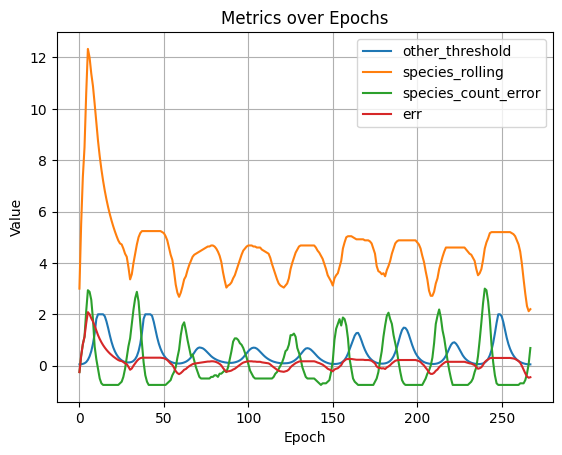

In [ ]:
collector.plot("other_threshold")  # , "species_rolling", "species_count_error", "err")
# collector.plot("err")

In [6]:
df = collector.to_polars()
df.filter(pl.col("name") == "count.species")
# df

name,last,sum,mean,stddev,var,skew,min,max,count,time_sum,time_mean,time_stddev,time_min,time_max,time_var,generation,update_count,tags
str,f64,f64,f64,f64,f64,f64,f64,f64,i64,duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],i64,i64,list[str]
"""count.species""",3.0,3.0,3.0,0.0,0.0,NaN,3.0,3.0,1,null,null,null,null,null,null,0,1,"[""species"", ""statistic""]"
"""count.species""",8.0,11.0,5.5,3.535534,12.5,NaN,3.0,8.0,2,null,null,null,null,null,null,1,1,"[""species"", ""statistic""]"
"""count.species""",11.0,22.0,7.333333,4.041452,16.333334,-1.532828,3.0,11.0,3,null,null,null,null,null,null,2,1,"[""species"", ""statistic""]"
"""count.species""",12.0,34.0,8.5,4.041452,16.333334,-1.908111,3.0,12.0,4,null,null,null,null,null,null,3,1,"[""species"", ""statistic""]"
"""count.species""",19.0,53.0,10.6,5.85662,34.299999,0.425879,3.0,19.0,5,null,null,null,null,null,null,4,1,"[""species"", ""statistic""]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""count.species""",1.0,1142.0,4.325758,4.248903,18.053175,1.627064,1.0,21.0,264,null,null,null,null,null,null,263,1,"[""species"", ""statistic""]"
"""count.species""",3.0,1145.0,4.320755,4.24163,17.991425,1.633444,1.0,21.0,265,null,null,null,null,null,null,264,1,"[""species"", ""statistic""]"
"""count.species""",6.0,1151.0,4.327068,4.234871,17.934132,1.630782,1.0,21.0,266,null,null,null,null,null,null,265,1,"[""species"", ""statistic""]"


In [7]:
df = collector.to_polars()
df

name,last,sum,mean,stddev,var,skew,min,max,count,time_sum,time_mean,time_stddev,time_min,time_max,time_var,generation,update_count,tags
str,f64,f64,f64,f64,f64,f64,f64,f64,i64,duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],i64,i64,list[str]
"""count.evaluation""",8.0,108.0,54.0,65.053825,4232.0,NaN,8.0,100.0,2,null,null,null,null,null,null,0,2,"[""statistic""]"
"""step.evaluate.time""",0.00001,0.000077,0.000039,0.00004,1.6127e-9,NaN,0.00001,0.000067,2,77µs,38µs,40µs,10µs,66µs,0µs,0,2,"[""time"", ""step""]"
"""selector.roulette""",20.0,20.0,20.0,0.0,0.0,NaN,20.0,20.0,1,null,null,null,null,null,null,0,1,"[""selector"", ""statistic""]"
"""selector.roulette.time""",0.000006,0.000006,0.000006,0.0,0.0,NaN,0.000006,0.000006,1,5µs,5µs,0µs,5µs,5µs,0µs,0,1,"[""selector"", ""time""]"
"""selector.tournament""",80.0,80.0,80.0,0.0,0.0,NaN,80.0,80.0,1,null,null,null,null,null,null,0,1,"[""selector"", ""statistic""]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""species_rolling""",2.2,1234.78064,4.60739,1.394277,1.944008,8.364057,2.12,12.333333,268,null,null,null,null,null,null,267,1,"[""species"", ""statistic"", ""expr""]"
"""species_count_error""",0.6875,22.645834,0.084499,0.969853,0.940615,0.0,-0.75,3.0,268,null,null,null,null,null,null,267,1,"[""species"", ""statistic"", ""expr""]"
"""other_threshold""",0.05,135.27269,0.504749,0.517485,0.267791,0.0,0.05,2.0,268,null,null,null,null,null,null,267,1,"[""other"", ""statistic"", ""expr""]"


In [8]:
print(result.index())
last_version = df.select("generation").max().item()
last_version

268


267